# PPO vs Everyone

The DeepQBot family (v1 -> dueling head -> 47-dim features -> Double DQN) is all
off-policy DQN, trained one match at a time via a custom Python loop -- part of why
2000-5000 episodes takes 10+ minutes run sequentially. PPO (Schulman et al., 2017) is
on-policy and trains through Stable-Baselines3's `model.learn()`, which:

- runs against `smeshlite.env.SmeshLiteEnv`, a real Gymnasium env already wired up
  for `agents/sb3_template.py`'s `SB3BrainTemplate`
- steps a `VecEnv` of multiple environments per update, instead of one match at a time
- handles its own rollout buffer, advantage estimation (GAE), and minibatch updates --
  no custom replay buffer / target network bookkeeping to write or debug

Starting simple, per the earlier discussion: the **raw 22-dim observation**
(`Character.obs_vector()` / `brain_context_to_obs()` -- position, velocity, damage,
stocks, action, action_frame, facing, in_air, charge, for self + opponent),
`MultiBinary(4)` actions (left/right/up/attack), and `SmeshLiteEnv`'s built-in reward
(`+dmg_dealt * 0.01` per tick, `+1.0` on KO, `-1.0` on death) -- no 47-dim feature
engineering yet.

The new piece is `agents/ppo_env.py::RoundRobinOpponentEnv`, a thin wrapper that
cycles player 1 through the same 4-opponent pool used by the DeepQBot notebooks
(`RandomBot -> ChaserBot -> SmeshBot -> frozen QTableBot -> repeat`) -- `SmeshLiteEnv`
normally gives player 1 a no-op. The trained policy is saved to
`agents/checkpoints/ppo_bot.zip` and exposed via `agents/ppo_bot.py::PPOBot` (a thin
subclass of `SB3BrainTemplate`) for use in `Match`-based evaluation/round-robin
notebooks alongside the other bots.

In [1]:
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mlflow
from tqdm.auto import tqdm

from stable_baselines3 import PPO
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.callbacks import BaseCallback

from agents.ppo_env import make_env, OPPONENT_NAMES

c:\Users\bonim\Documents\Uni\SmeshLite\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Environment & model

`make_vec_env(make_env, n_envs=N_ENVS, seed=0)` builds `N_ENVS` independent
`RoundRobinOpponentEnv` instances (each its own `SmeshLiteEnv` + opponent cycle). The
`seed=0` makes each env's `RoundRobinOpponentEnv.reset(seed=...)` start at a different
point in `OPPONENT_CYCLE`, so the envs aren't all fighting the same opponent at once.

`make_vec_env`'s default `DummyVecEnv` steps all `N_ENVS` environments sequentially
within this one process -- no multiprocessing yet. That still gives PPO an
`N_ENVS`-wide batch of experience per update (vs. DQN's one-match-at-a-time loop), and
SB3 makes it a one-line change to `vec_env_cls=SubprocVecEnv` for real multiprocess
parallelism later, once this baseline is working.

PPO hyperparameters start at SB3's defaults (`n_steps=2048`, `batch_size=64`,
`gamma=0.99`, `gae_lambda=0.95`, `clip_range=0.2`, `ent_coef=0.0`, learning rate
`3e-4`). `gamma=0.99` (vs. the DQN family's `0.95`) is PPO's own default -- GAE
already trades off bias/variance, and matches are short enough (`time_limit=1800`
frames) that the difference should be small. `device="cpu"`: SB3 recommends CPU for
small MLP policies with PPO/A2C -- the bottleneck here is the Python match
simulation, not the network, so GPU transfer overhead would only slow things down.

In [2]:
N_ENVS = 8
TOTAL_TIMESTEPS = 500_000

vec_env = make_vec_env(make_env, n_envs=N_ENVS, seed=0)
print("obs space:", vec_env.observation_space)
print("action space:", vec_env.action_space)

model = PPO("MlpPolicy", vec_env, verbose=0, device="cpu")
print("device:", model.device)

obs space: Box(-2000.0, 2000.0, (22,), float32)
action space: MultiBinary(4)
device: cpu


## Training loop

`model.learn(total_timesteps=TOTAL_TIMESTEPS, callback=callback)` runs PPO's normal
training loop: collect `n_steps` ticks per env (`n_steps * N_ENVS` total), compute
advantages (GAE), then `n_epochs` passes of minibatch SGD over that batch, repeated
until `TOTAL_TIMESTEPS` total environment steps.

`EpisodeLoggingCallback` below hooks `_on_step()` (called once per `model.learn()`
step, i.e. once per `N_ENVS` environment ticks) and, for each sub-environment whose
episode just ended (`dones[i]`), appends one row to `history` -- mirroring the
DeepQBot notebooks' per-episode `history`/`df`:

- `opponent` / `winner` / `frames` come from `RoundRobinOpponentEnv`'s `info` dict
  (`SmeshLiteEnv.step()` + our wrapper)
- `episode_reward` comes from SB3's `Monitor` wrapper (`info["episode"]["r"]`), which
  `make_vec_env` applies automatically
- `timesteps` is `self.num_timesteps`, the cumulative environment-step count at that
  point -- PPO's analogue of `buffer_len`'s monotonic progress

Every `LOG_EVERY` *episodes* (not timesteps -- episode lengths vary), the trailing
window is aggregated into the same `win_rate` / `avg_reward` / per-opponent metrics
the DeepQBot notebooks log, at `step=len(history)`, into a new MLflow experiment
`"ppo_vs_all"`.

In [3]:
LOG_EVERY = 100


class EpisodeLoggingCallback(BaseCallback):
    """Collects one row per finished episode (across all parallel envs) into
    `history`, and logs rolling win-rate / reward to MLflow every LOG_EVERY episodes.
    Also drives a tqdm progress bar over `total_timesteps`."""

    def __init__(self, log_every: int = LOG_EVERY, verbose: int = 0):
        super().__init__(verbose)
        self.log_every = log_every
        self.history: list[dict] = []
        self.pbar: tqdm | None = None

    def _on_training_start(self) -> None:
        self.pbar = tqdm(total=self.locals["total_timesteps"], desc="PPO", unit="step")

    def _on_step(self) -> bool:
        self.pbar.update(self.training_env.num_envs)
        for info, done in zip(self.locals["infos"], self.locals["dones"]):
            if not done:
                continue
            self.history.append({
                "episode": len(self.history) + 1,
                "opponent": info["opponent"],
                "winner": info["winner"],
                "frames": info["frame"],
                "episode_reward": info["episode"]["r"],
                "timesteps": self.num_timesteps,
            })
            if len(self.history) % self.log_every == 0:
                recent = pd.DataFrame(self.history[-self.log_every:])
                metrics = {
                    "win_rate": (recent["winner"] == 0).mean(),
                    "avg_reward": recent["episode_reward"].mean(),
                }
                for opp_name, group in recent.groupby("opponent"):
                    metrics[f"win_rate_{opp_name}"] = (group["winner"] == 0).mean()
                    metrics[f"avg_reward_{opp_name}"] = group["episode_reward"].mean()
                mlflow.log_metrics(metrics, step=len(self.history))
                self.pbar.set_postfix(win_rate=f"{metrics['win_rate']:.2f}", avg_reward=f"{metrics['avg_reward']:+.2f}")
                tqdm.write(f"episode {len(self.history):5d} (step {self.num_timesteps:7d}): "
                           f"win_rate={metrics['win_rate']:.2f} avg_reward={metrics['avg_reward']:+.3f}")
        return True

    def _on_training_end(self) -> None:
        self.pbar.close()

In [4]:
mlflow.set_tracking_uri("http://localhost:5000")
mlflow.set_experiment("ppo_vs_all")

callback = EpisodeLoggingCallback()

with mlflow.start_run(run_name=f"ppo_{time.strftime('%Y%m%d_%H%M%S')}") as run:
    run_id = run.info.run_id
    mlflow.log_params({
        "n_envs": N_ENVS,
        "total_timesteps": TOTAL_TIMESTEPS,
        "gamma": model.gamma,
        "gae_lambda": model.gae_lambda,
        "n_steps": model.n_steps,
        "batch_size": model.batch_size,
        "n_epochs": model.n_epochs,
        "learning_rate": model.learning_rate,
        "log_every": LOG_EVERY,
        "opponent_cycle": ", ".join(OPPONENT_NAMES),
        "device": str(model.device),
    })

    t0 = time.time()
    model.learn(total_timesteps=TOTAL_TIMESTEPS, callback=callback)
    print(f"done in {time.time() - t0:.1f}s, {len(callback.history)} episodes")

df = pd.DataFrame(callback.history)
df.tail()

2026/06/15 16:00:55 INFO mlflow.tracking.fluent: Experiment with name 'ppo_vs_all' does not exist. Creating a new experiment.
PPO:  32%|███▏      | 160840/500000 [02:51<06:55, 815.39step/s, avg_reward=+0.15, win_rate=0.33] 

episode   100 (step  160168): win_rate=0.33 avg_reward=+0.154


PPO:  66%|██████▌   | 329464/500000 [06:24<10:56, 259.66step/s, avg_reward=+1.51, win_rate=0.59] 

episode   200 (step  328680): win_rate=0.59 avg_reward=+1.509


PPO: 500088step [12:10, 238.24step/s, avg_reward=+2.38, win_rate=0.81]                           

episode   300 (step  499912): win_rate=0.81 avg_reward=+2.382


PPO: 507904step [12:49, 659.96step/s, avg_reward=+2.38, win_rate=0.81] 


done in 769.6s, 306 episodes
🏃 View run ppo_20260615_160055 at: http://localhost:5000/#/experiments/8/runs/114bda60e7464611ae3b280d74508737
🧪 View experiment at: http://localhost:5000/#/experiments/8


,episode,opponent,winner,frames,episode_reward,timesteps
301,302,QTableBot,0,1579,5.3835,501784
302,303,ChaserBot,0,1800,4.7275,502688
303,304,SmeshBot,0,1800,4.8675,504312
304,305,ChaserBot,0,1800,2.7250,504472
305,306,SmeshBot,0,1800,2.6450,507248


## Results

Same shape as the DeepQBot notebooks' results section, plus `frames` (match length)
since it's free here and was one of the "episode-level diagnostics" added to
`doubledeepq_vs_all.ipynb` -- a KO-speed trend is worth watching from the start rather
than retrofitting later.

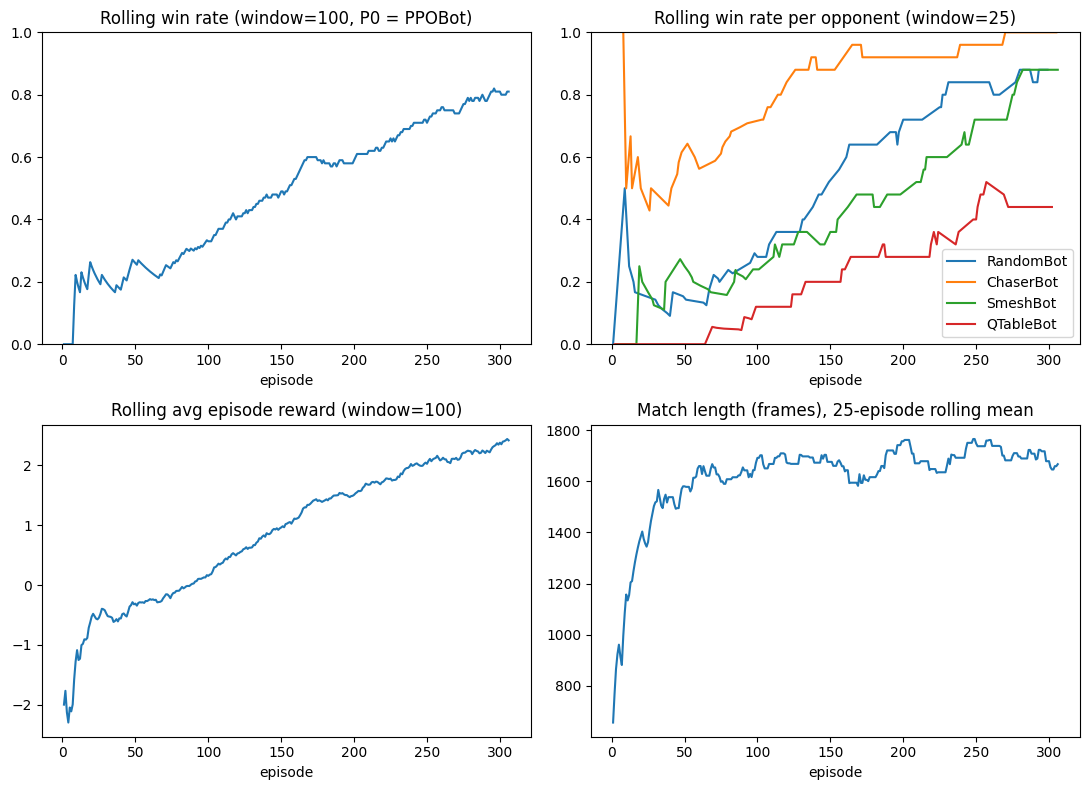

In [5]:
win_rolling = (df["winner"] == 0).rolling(100, min_periods=1).mean()
reward_rolling = df["episode_reward"].rolling(100, min_periods=1).mean()

fig, axes = plt.subplots(2, 2, figsize=(11, 8))

axes[0, 0].plot(df["episode"], win_rolling)
axes[0, 0].set_ylim(0, 1)
axes[0, 0].set_title("Rolling win rate (window=100, P0 = PPOBot)")
axes[0, 0].set_xlabel("episode")

for opp_name in OPPONENT_NAMES:
    mask = df["opponent"] == opp_name
    opp_win_rolling = (df.loc[mask, "winner"] == 0).rolling(25, min_periods=1).mean()
    axes[0, 1].plot(df.loc[mask, "episode"], opp_win_rolling, label=opp_name)
axes[0, 1].set_ylim(0, 1)
axes[0, 1].set_title("Rolling win rate per opponent (window=25)")
axes[0, 1].set_xlabel("episode")
axes[0, 1].legend()

axes[1, 0].plot(df["episode"], reward_rolling)
axes[1, 0].set_title("Rolling avg episode reward (window=100)")
axes[1, 0].set_xlabel("episode")

axes[1, 1].plot(df["episode"], df["frames"].rolling(25, min_periods=1).mean())
axes[1, 1].set_title("Match length (frames), 25-episode rolling mean")
axes[1, 1].set_xlabel("episode")

fig.tight_layout()

## Save checkpoint

Saves the trained policy to `agents/checkpoints/ppo_bot.zip` -- the default path
`agents/ppo_bot.py::PPOBot` loads, so `PPOBot()` can be dropped into any `Match`-based
notebook (round-robin vs-all, head-to-head vs DeepQBot/DoubleDeepQBot, etc.) the same
way the other bots are.

In [6]:
checkpoint_path = "agents/checkpoints/ppo_bot.zip"
model.save(checkpoint_path)

with mlflow.start_run(run_id=run_id):
    mlflow.log_artifact(checkpoint_path)

print(f"Saved PPO policy ({model.num_timesteps} steps trained) to {checkpoint_path}")

🏃 View run ppo_20260615_160055 at: http://localhost:5000/#/experiments/8/runs/114bda60e7464611ae3b280d74508737
🧪 View experiment at: http://localhost:5000/#/experiments/8
Saved PPO policy (507904 steps trained) to agents/checkpoints/ppo_bot.zip
